In [17]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import metpy.calc as mpcalc
from metpy.units import units
from pathlib import Path
from tqdm.auto import tqdm


In [7]:
data_path = Path('../data/era5_2021-nov_250-500-925_uv_pv_gph.nc')
ds = xr.open_dataset(data_path)
ds


<xarray.Dataset> Size: 36GB
Dimensions:         (valid_time: 720, pressure_level: 3, latitude: 721,
                     longitude: 1440)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 6kB 2021-11-01 ... 2021-11-30...
  * pressure_level  (pressure_level) float64 24B 925.0 500.0 250.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    number          int64 8B ...
    expver          (valid_time) <U4 12kB ...
Data variables:
    z               (valid_time, pressure_level, latitude, longitude) float32 9GB ...
    pv              (valid_time, pressure_level, latitude, longitude) float32 9GB ...
    u               (valid_time, pressure_level, latitude, longitude) float32 9GB ...
    v               (valid_time, pressure_level, latitude, longitude) float32 9GB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-25T22:57 GRIB to CDM+CF via cfgrib-0.9.1...

<xarray.Dataset> Size: 8MB
Dimensions:         (latitude: 721, longitude: 1440)
Coordinates:
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    number          int64 8B ...
    valid_time      datetime64[ns] 8B 2021-11-12T15:00:00
    pressure_level  float64 8B 925.0
    expver          <U4 16B ...
Data variables:
    u               (latitude, longitude) float32 4MB ...
    v               (latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-25T22:57 GRIB to CDM+CF via cfgrib-0.9.1...

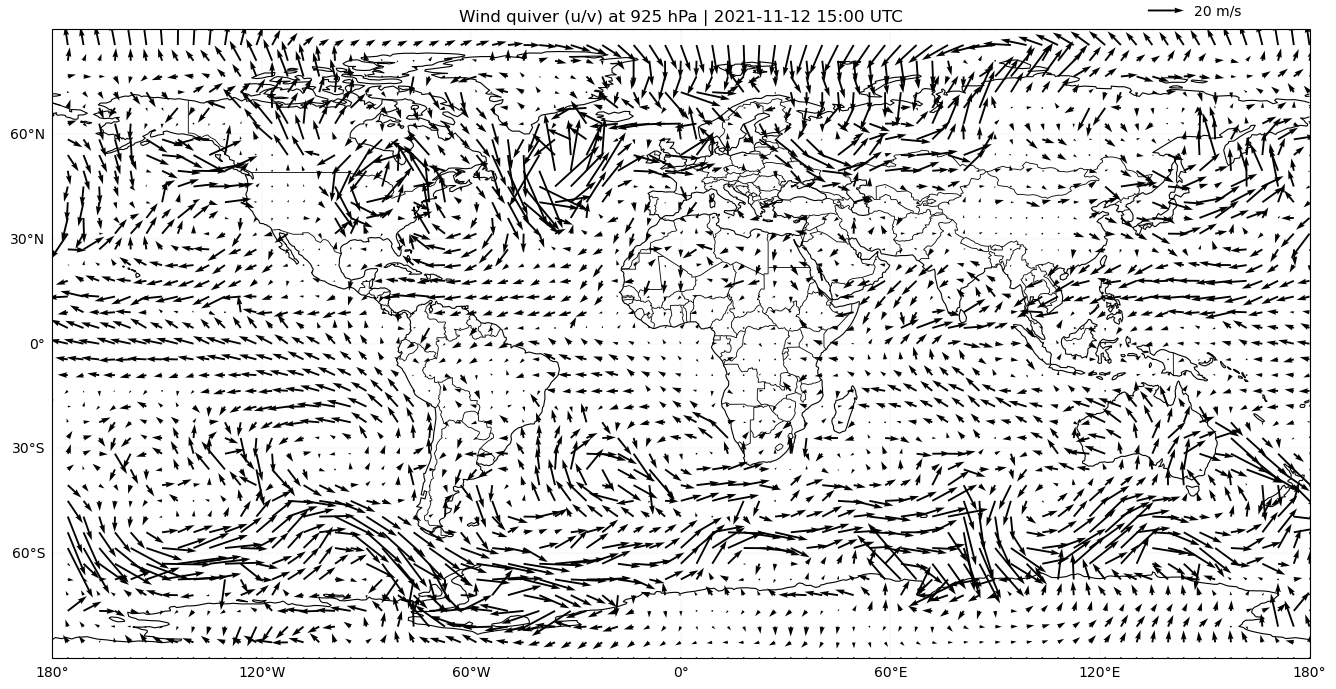

In [13]:
def plot_wind_quiver_at_time_cartopy(
    ds,
    when="2021-11-12T15:00:00",
    pressure_level=925,
    stride=20,
    scale=700,
    extent=None,
):
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    target_time = np.datetime64(when)
    wind = ds[["u", "v"]].sel(
        valid_time=target_time, pressure_level=pressure_level, method="nearest"
    ).squeeze(drop=True)

    u = wind["u"]
    v = wind["v"]

    u_sub = u.isel(latitude=slice(None, None, stride), longitude=slice(None, None, stride))
    v_sub = v.isel(latitude=slice(None, None, stride), longitude=slice(None, None, stride))
    lon_sub = u_sub["longitude"]
    lat_sub = u_sub["latitude"]

    fig = plt.figure(figsize=(14, 7))
    ax = plt.axes(projection=ccrs.PlateCarree())

    if extent is not None:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    else:
        ax.set_global()

    # Draw only boundary lines, no filled land polygons.
    ax.coastlines(resolution="110m", linewidth=0.8, color="black")
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor="black")

    quiv = ax.quiver(
        lon_sub,
        lat_sub,
        u_sub,
        v_sub,
        transform=ccrs.PlateCarree(),
        scale=scale,
        width=0.0015,
    )
    ax.quiverkey(quiv, 0.9, 1.03, 20, "20 m/s", labelpos="E")

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    actual_time = pd.to_datetime(wind["valid_time"].values).strftime("%Y-%m-%d %H:%M UTC")
    ax.set_title(f"Wind quiver (u/v) at {pressure_level} hPa | {actual_time}")
    plt.tight_layout()
    return wind, fig, ax

wind_2021_11_12_15utc, fig, ax = plot_wind_quiver_at_time_cartopy(
    ds,
    when="2021-11-12T15:00:00",
    pressure_level=925,
    stride=18,
)
wind_2021_11_12_15utc


In [14]:
VANCOUVER_LAT = 49.28
VANCOUVER_LON = -123.12  # degrees East/West convention (West is negative)
VANCOUVER_LON_360 = VANCOUVER_LON % 360
VANCOUVER_LAT, VANCOUVER_LON, VANCOUVER_LON_360


(49.28, -123.12, 236.88)

Backward integration: 100%|██████████| 72/72 [02:52<00:00,  2.40s/h]


,step_hour,valid_time,latitude,longitude
0,0,2021-11-12 15:00:00,49.280000,236.880000
1,1,2021-11-12 14:00:00,49.197853,236.595014
2,2,2021-11-12 13:00:00,49.099506,236.167762
3,3,2021-11-12 12:00:00,48.949713,235.744306
4,4,2021-11-12 11:00:00,48.809200,235.392474


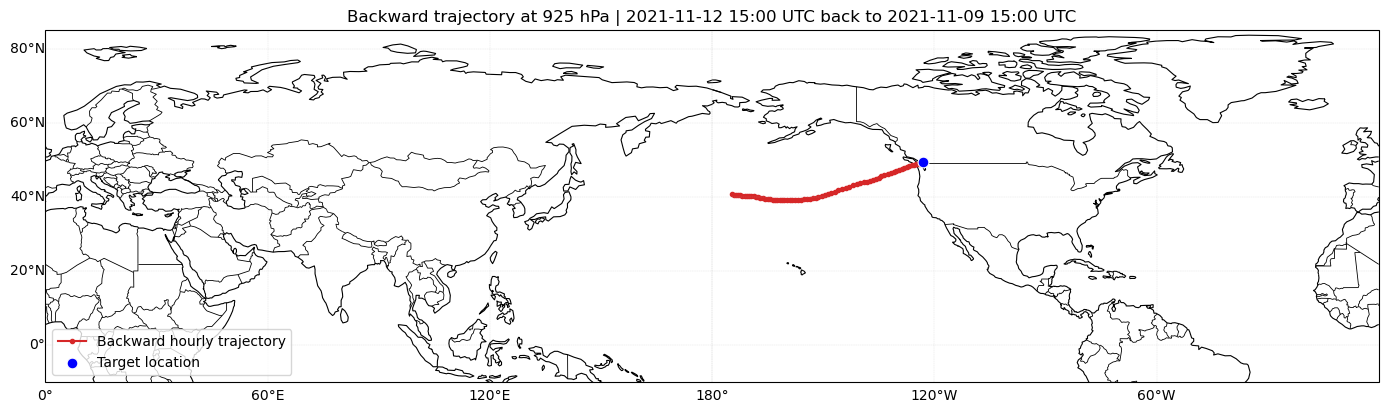

In [21]:
def backward_integrate_trajectory_uv(
    ds,
    start_lat,
    start_lon,
    start_time,
    pressure_level=925,
    hours_back=72,
    substeps=4,
    earth_radius_m=6_371_000.0,
):
    """Backward trajectory using ERA5 u/v winds.

    Returns a DataFrame with hourly positions from target time backward.
    """
    if substeps < 1:
        raise ValueError("substeps must be >= 1")

    # Optimization: preselect pressure level and relevant time window once.
    ds_uv = ds[["u", "v"]].sel(pressure_level=pressure_level)
    t0 = pd.Timestamp(start_time).to_datetime64()
    t_nearest = ds_uv["valid_time"].sel(valid_time=t0, method="nearest").values

    # Extra margin keeps interpolation safe near the backward-window edge.
    window_start = np.datetime64(t_nearest) - np.timedelta64(hours_back + 2, "h")
    ds_uv = ds_uv.sel(valid_time=slice(window_start, np.datetime64(t_nearest))).load()

    times = pd.to_datetime(ds_uv["valid_time"].values)
    lat = float(start_lat)
    lon = float(start_lon) % 360.0

    records = [
        {
            "step_hour": 0,
            "valid_time": pd.Timestamp(t_nearest),
            "latitude": lat,
            "longitude": lon,
        }
    ]

    dt_hour_s = 3600.0
    dt_sub_s = dt_hour_s / substeps

    t_curr = np.datetime64(t_nearest)
    t_min = np.datetime64(times.min().to_datetime64())

    for h in tqdm(range(1, hours_back + 1), desc="Backward integration", unit="h"):
        if t_curr - np.timedelta64(1, "h") < t_min:
            break

        lat_step = lat
        lon_step = lon

        for s in range(substeps):
            sec_back = (s + 0.5) * dt_sub_s
            t_mid = t_curr - np.timedelta64(int(sec_back), "s")

            uv = ds_uv.interp(
                valid_time=t_mid,
                latitude=lat_step,
                longitude=lon_step,
                kwargs={"fill_value": "extrapolate"},
            )

            u_ms = float(uv["u"].values)
            v_ms = float(uv["v"].values)

            dlat_deg = np.degrees((v_ms * dt_sub_s) / earth_radius_m)
            coslat = max(np.cos(np.radians(lat_step)), 1e-6)
            dlon_deg = np.degrees((u_ms * dt_sub_s) / (earth_radius_m * coslat))

            # Backward integration: previous position = current - forward displacement.
            lat_step = float(np.clip(lat_step - dlat_deg, -89.75, 89.75))
            lon_step = float((lon_step - dlon_deg) % 360.0)

        t_curr = t_curr - np.timedelta64(1, "h")
        lat = lat_step
        lon = lon_step

        records.append(
            {
                "step_hour": h,
                "valid_time": pd.Timestamp(t_curr),
                "latitude": lat,
                "longitude": lon,
            }
        )

    return pd.DataFrame(records)


def plot_back_trajectory_cartopy(track_df, target_lat, target_lon, pressure_level=925):
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    proj = ccrs.PlateCarree(central_longitude=180)
    fig = plt.figure(figsize=(14, 7))
    ax = plt.axes(projection=proj)

    # Left edge at Greenwich (0 deg), center near the western Pacific / Russia side.
    ax.set_extent([0, 360, -10, 85], crs=ccrs.PlateCarree())

    ax.coastlines(resolution="110m", linewidth=0.8, color="black")
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor="black")

    lons = track_df["longitude"].to_numpy()
    lats = track_df["latitude"].to_numpy()

    ax.plot(
        lons,
        lats,
        "-o",
        color="tab:red",
        markersize=3,
        linewidth=1.5,
        transform=ccrs.PlateCarree(),
        label="Backward hourly trajectory",
    )

    ax.scatter(
        [target_lon % 360.0],
        [target_lat],
        s=60,
        color="blue",
        edgecolor="white",
        linewidth=0.8,
        transform=ccrs.PlateCarree(),
        zorder=5,
        label="Target location",
    )

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    t_start = pd.to_datetime(track_df["valid_time"].iloc[0]).strftime("%Y-%m-%d %H:%M UTC")
    t_end = pd.to_datetime(track_df["valid_time"].iloc[-1]).strftime("%Y-%m-%d %H:%M UTC")
    ax.set_title(
        f"Backward trajectory at {pressure_level} hPa | {t_start} back to {t_end}"
    )
    ax.legend(loc="lower left")
    plt.tight_layout()
    return fig, ax


trajectory_df = backward_integrate_trajectory_uv(
    ds,
    start_lat=VANCOUVER_LAT,
    start_lon=VANCOUVER_LON,
    start_time="2021-11-12T15:00:00",
    pressure_level=925,
    hours_back=72,
    substeps=4,
)

fig, ax = plot_back_trajectory_cartopy(
    trajectory_df,
    target_lat=VANCOUVER_LAT,
    target_lon=VANCOUVER_LON,
    pressure_level=925,
)

trajectory_df.head()
